# Lab 02 - Taylor Polynomials and Taylor Series

Solutions for all mandatory tasks from `L2_NC.pdf` (plus optional exercise 4), implemented in Python.

We use the criterion:
$$
|\text{error}| < 0.5 \cdot 10^{-d}
$$
for `d` correct decimals.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')


def threshold_for_decimals(decimals: int) -> float:
    return 0.5 * 10 ** (-decimals)


def has_correct_decimals(approx: float, truth: float, decimals: int) -> bool:
    return abs(approx - truth) < threshold_for_decimals(decimals)


def taylor_exp(x, degree: int):
    x = np.asarray(x)
    total = np.zeros_like(x, dtype=float)
    for k in range(degree + 1):
        total += x**k / math.factorial(k)
    return total


def taylor_sin(x, degree: int):
    x = np.asarray(x)
    total = np.zeros_like(x, dtype=float)
    max_m = (degree - 1) // 2
    for m in range(max_m + 1):
        total += ((-1) ** m) * x ** (2 * m + 1) / math.factorial(2 * m + 1)
    return total


def taylor_ln1p(x, degree: int):
    x = np.asarray(x)
    total = np.zeros_like(x, dtype=float)
    for k in range(1, degree + 1):
        total += ((-1) ** (k - 1)) * x**k / k
    return total


## Exercise 1

Using
$$
e^x = 1 + x + \frac{x^2}{2!} + \dots + \frac{x^n}{n!} + R_{n+1}(x)
$$
we solve items (a) and (b).

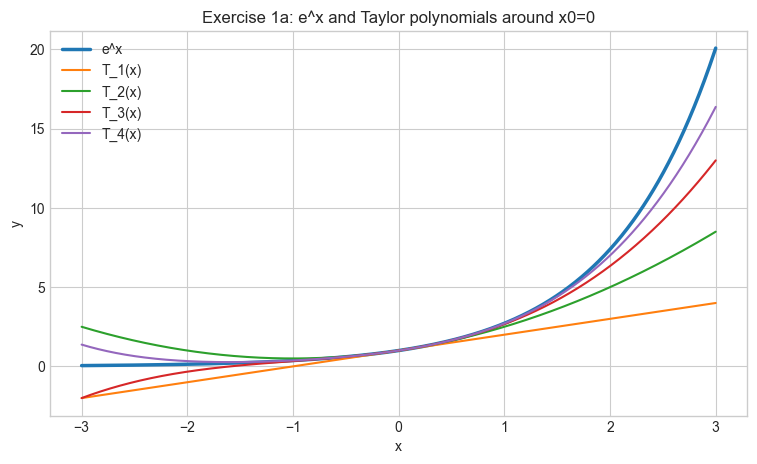

Minimum degree for 6 correct decimals at x=1: n=9
Approximation of e: 2.718281525573
Absolute error: 3.029e-07


In [2]:
# 1a) Plot e^x and Taylor polynomials of degree 1,2,3,4 on [-3, 3]
x = np.linspace(-3, 3, 1000)
y_true = np.exp(x)

plt.figure(figsize=(9, 5))
plt.plot(x, y_true, label='e^x', linewidth=2.5)
for n in [1, 2, 3, 4]:
    plt.plot(x, taylor_exp(x, n), label=f'T_{n}(x)')
plt.title('Exercise 1a: e^x and Taylor polynomials around x0=0')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# 1b) Approximate e with 6 correct decimals
target = math.e
best_n = None
best_approx = None
for n in range(0, 40):
    approx = float(taylor_exp(np.array([1.0]), n)[0])
    if has_correct_decimals(approx, target, 6):
        best_n = n
        best_approx = approx
        break

print(f'Minimum degree for 6 correct decimals at x=1: n={best_n}')
print(f'Approximation of e: {best_approx:.12f}')
print(f'Absolute error: {abs(best_approx - target):.3e}')

## Exercise 2

Using
$$
\sin x = x - \frac{x^3}{3!} + \frac{x^5}{5!} - \dots
$$
we solve items (a), (b), and (c).

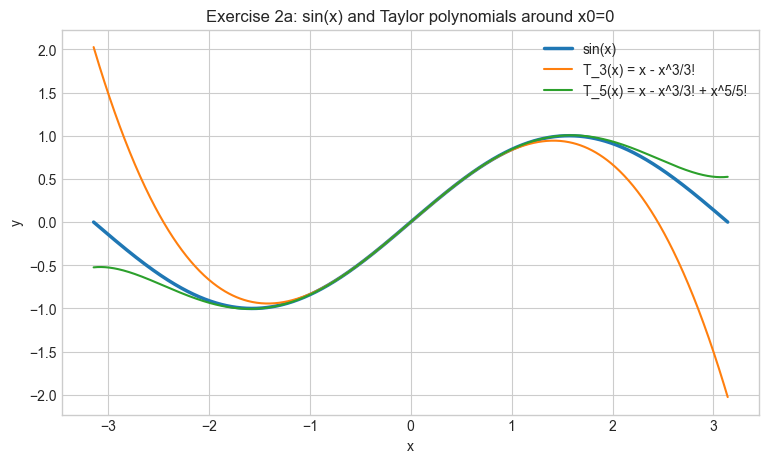

Minimum odd degree for 5 correct decimals at x=pi/5: 7
Number of terms: 4
Approximation: 0.5877852104
Actual value:  0.5877852523
Absolute error: 4.191e-08

Exercise 2c:
x = 10*pi/3 = 10.471976
T_5(x) at original x: 868.525428 (very poor)
sin(x) exact: -0.866025
Reduced x in [-pi, pi]: -2.094395
T_5(reduced x): -0.899045 (much better)
Explanation: Maclaurin truncations are accurate near x=0 and degrade for large |x|.
Solution: use periodicity (range reduction), then apply Taylor polynomial.


In [9]:
# 2a) Plot sin(x) with degree 3 and degree 5 polynomials on [-pi, pi]
x = np.linspace(-np.pi, np.pi, 1000)
y_true = np.sin(x)

plt.figure(figsize=(9, 5))
plt.plot(x, y_true, label='sin(x)', linewidth=2.5)
plt.plot(x, taylor_sin(x, 3), label='T_3(x) = x - x^3/3!')
plt.plot(x, taylor_sin(x, 5), label='T_5(x) = x - x^3/3! + x^5/5!')
plt.title('Exercise 2a: sin(x) and Taylor polynomials around x0=0')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# 2b) Approximate sin(pi/5) with 5 correct decimals
x0 = np.pi / 5
truth = math.sin(x0)

best_deg = None
best_approx = None
for deg in range(1, 31, 2):
    approx = float(taylor_sin(np.array([x0]), deg)[0])
    if has_correct_decimals(approx, truth, 5):
        best_deg = deg
        best_approx = approx
        break

print(f'Minimum odd degree for 5 correct decimals at x=pi/5: {best_deg}')
print(f'Number of terms: {best_deg // 2 + 1}')
print(f'Approximation: {best_approx:.10f}')
print(f'Actual value:  {truth:.10f}')
print(f'Absolute error: {abs(best_approx - truth):.3e}')

# 2c) Behavior at x = 10*pi/3 and fix via periodicity
x_big = 10 * np.pi / 3
naive_deg = 5
naive = float(taylor_sin(np.array([x_big]), naive_deg)[0])
true_big = math.sin(x_big)

# Reduce argument to principal value in [-pi, pi] using periodicity sin(x) = sin(x - 2k*pi)
x_reduced = ((x_big + np.pi) % (2 * np.pi)) - np.pi
reduced_approx = float(taylor_sin(np.array([x_reduced]), naive_deg)[0])

print('\nExercise 2c:')
print(f'x = 10*pi/3 = {x_big:.6f}')
print(f'T_{naive_deg}(x) at original x: {naive:.6f} (very poor)')
print(f'sin(x) exact: {true_big:.6f}')
print(f'Reduced x in [-pi, pi]: {x_reduced:.6f}')
print(f'T_{naive_deg}(reduced x): {reduced_approx:.6f} (much better)')
print('Explanation: Maclaurin truncations are accurate near x=0 and degrade for large |x|.')
print('Solution: use periodicity (range reduction), then apply Taylor polynomial.')

## Exercise 3

Using
$$
\ln(1+x) = x - \frac{x^2}{2} + \frac{x^3}{3} - \dots, \quad |x| < 1
$$
we solve items (a) to (e).

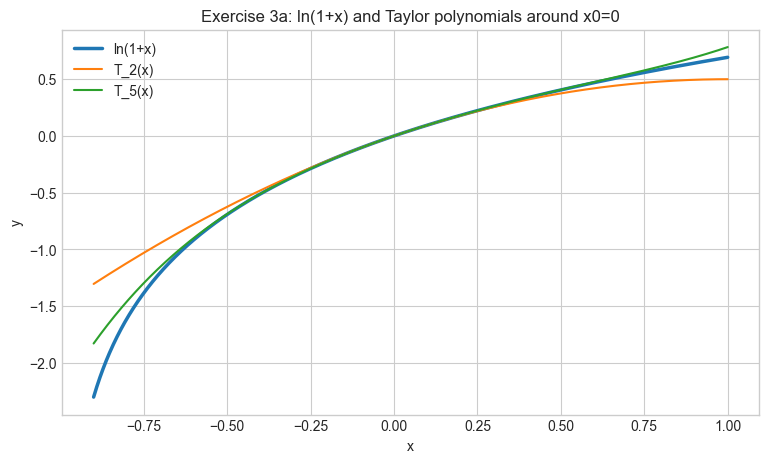

Exercise 3b:
Terms needed by direct check: 100000
Safe bound from alternating-series remainder: about 200000 terms

Exercise 3c:
ln(1-x) = -(x + x^2/2 + x^3/3 + ...),  |x|<1

Exercise 3d:
ln((1+x)/(1-x)) = ln(1+x) - ln(1-x) = 2*(x + x^3/3 + x^5/5 + ...), |x|<1

Exercise 3e:
Approximation of ln(2): 0.6931460474
Absolute error: 1.133e-06
Number of terms needed in 2*(x + x^3/3 + ...), x=1/3: 5


In [11]:
# 3a) Plot ln(1+x) and degrees 2 and 5 on [-0.9, 1]
x = np.linspace(-0.9, 1.0, 1000)
y_true = np.log1p(x)

plt.figure(figsize=(9, 5))
plt.plot(x, y_true, label='ln(1+x)', linewidth=2.5)
plt.plot(x, taylor_ln1p(x, 2), label='T_2(x)')
plt.plot(x, taylor_ln1p(x, 5), label='T_5(x)')
plt.title('Exercise 3a: ln(1+x) and Taylor polynomials around x0=0')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# 3b) Terms needed in ln(1+x) series to approximate ln(2) with 5 correct decimals
# Here x=1 -> alternating harmonic series: ln(2)=1-1/2+1/3-...
truth_ln2 = math.log(2)
thr = threshold_for_decimals(5)

partial = 0.0
n_needed_actual = None
for n in range(1, 400_001):
    partial += ((-1) ** (n - 1)) / n
    if abs(partial - truth_ln2) < thr:
        n_needed_actual = n
        break

# If we keep n terms, Leibniz gives |R_n| <= 1/(n+1).
# Need 1/(n+1) < thr  =>  n > 1/thr - 1, so the smallest integer n is ceil(1/thr - 1).
n_needed_bound = math.ceil(1 / thr - 1)

print('Exercise 3b:')
print(f'Terms needed by direct check: {n_needed_actual}')
print(f'Safe bound from alternating-series remainder: {n_needed_bound} terms')

# 3c) Series for ln(1-x) from formula (5): substitute x -> -x
print('\nExercise 3c:')
print('ln(1-x) = -(x + x^2/2 + x^3/3 + ...),  |x|<1')

# 3d) Derive series for ln((1+x)/(1-x))
print('\nExercise 3d:')
print('ln((1+x)/(1-x)) = ln(1+x) - ln(1-x) = 2*(x + x^3/3 + x^5/5 + ...), |x|<1')

# 3e) Approximate ln(2) using formula from 3d)
# Choose x such that (1+x)/(1-x)=2 -> x=1/3
x_star = 1 / 3
truth = math.log(2)
partial = 0.0
n_terms_3e = 0
for m in range(0, 1000):
    partial += 2 * (x_star ** (2 * m + 1)) / (2 * m + 1)
    n_terms_3e = m + 1
    if abs(partial - truth) < threshold_for_decimals(5):
        break

print('\nExercise 3e:')
print(f'Approximation of ln(2): {partial:.10f}')
print(f'Absolute error: {abs(partial - truth):.3e}')
print(f'Number of terms needed in 2*(x + x^3/3 + ...), x=1/3: {n_terms_3e}')

## Optional Exercise 4

Approximate
$$
\sqrt[3]{999}
$$
using formula (6) for $(1+x)^a$.

We write:
$$
\sqrt[3]{999} = 10\,(0.999)^{1/3} = 10\,(1-0.001)^{1/3}
$$
with $a=1/3$ and $x=-0.001$ (valid because $|x|<1$).

In [6]:
def binom_real(a: float, k: int) -> float:
    if k == 0:
        return 1.0
    num = 1.0
    for j in range(k):
        num *= (a - j)
    return num / math.factorial(k)


a = 1 / 3
x = -0.001
truth = 999 ** (1 / 3)

partial = 0.0
n_used = 0
for k in range(0, 100):
    partial += binom_real(a, k) * (x ** k)
    approx = 10 * partial
    n_used = k
    if has_correct_decimals(approx, truth, 10):
        break

print(f'Approximation for cbrt(999): {approx:.12f}')
print(f'Exact value (Python):        {truth:.12f}')
print(f'Absolute error: {abs(approx - truth):.3e}')
print(f'Maximum polynomial degree used: {n_used}')

Approximation for cbrt(999): 9.996665554938
Exact value (Python):        9.996665554938
Absolute error: 4.121e-13
Maximum polynomial degree used: 3
